# LightGBM Baseline

##  Импорты

In [1]:
!pip install lightgbm optuna shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import optuna
import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from IPython.display import display

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 1208
np.random.seed(SEED)

In [3]:
import os

## Пути и константы

In [12]:
import pandas as pd
import pickle

BASE_DIR   = '/content'

TRAIN_PATH   = os.path.join(BASE_DIR, 'df_train.csv')
TEST_PATH    = os.path.join(BASE_DIR, 'df_test.csv')
OOT_PATH     = os.path.join(BASE_DIR, 'df_oot.csv')
VARIANT_DIR  = './'
SCALER_PATH  = os.path.join(BASE_DIR, 'scaler_baseline.pkl')
MEDIAN_PATH  = os.path.join(BASE_DIR, 'median_store.pkl')

VARIANT_NAMES = ['I', 'II', 'III', 'IV', 'V']
TARGET = 'fraud_bool'

FEATURES = [
    'name_email_similarity', 'session_length_in_minutes', 'zip_count_4w',
    'velocity_6h', 'credit_risk_score', 'zip_count_4w_clean',
    'current_address_months_count_clean', 'date_of_birth_distinct_emails_4w',
    'bank_branch_count_8w_clean', 'bank_months_count', 'income',
    'proposed_credit_limit', 'customer_age', 'device_os_windows',
    'email_is_free', 'phone_home_valid', 'keep_alive_session',
    'phone_mobile_valid', 'housing_status_BC', 'payment_type_AB',
    'payment_type_AC', 'housing_status_BB', 'foreign_request',
    'payment_type_AD', 'has_other_cards', 'prev_address_months_count_clean',
    'employment_status_CB', 'employment_status_CC', 'device_os_other',
    'device_os_macintosh', 'housing_status_BE', 'housing_status_BD',
    'source_TELEAPP', 'employment_status_CD', 'device_os_x11'
]


In [13]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
oot_df   = pd.read_csv(OOT_PATH)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]
X_oot,   y_oot   = oot_df[FEATURES],   oot_df[TARGET]

In [14]:
variants = {}
for v in VARIANT_NAMES:
    path = f'{VARIANT_DIR}Variant {v}.csv'
    try:
        df_v = pd.read_csv(path)
        variants[v] = (df_v[FEATURES], df_v[TARGET])
        print(f'  Variant {v}: {len(df_v):,} строк, фрод {df_v[TARGET].mean():.4f}')
    except FileNotFoundError:
        print(f'  Variant {v}: файл не найден, пропускаем')

  Variant I: 1,000,000 строк, фрод 0.0110
  Variant II: 1,000,000 строк, фрод 0.0110
  Variant III: 1,000,000 строк, фрод 0.0110
  Variant IV: 1,000,000 строк, фрод 0.0110
  Variant V: 1,000,000 строк, фрод 0.0110


In [17]:
import joblib

scaler = joblib.load(SCALER_PATH)
median_store = joblib.load(MEDIAN_PATH)

## Подбор гиперпараметров (Optuna)
Целевая метрика — **PR-AUC** на тестовой выборке.  
Это осмысленно для несбалансированных данных: именно PR-AUC чувствителен к качеству предсказания меньшинства (фрод).

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (авто, neg/pos): {scale_pos_weight:.1f}')

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'verbosity': -1,
        'seed': SEED,
        'scale_pos_weight': scale_pos_weight,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    preds = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, preds)

N_TRIALS = 50
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nЛучший PR-AUC (test): {study.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

scale_pos_weight (авто, neg/pos): 99.2


  0%|          | 0/50 [00:00<?, ?it/s]


Лучший PR-AUC (test): 0.1723
Лучшие параметры:
  n_estimators: 1000
  learning_rate: 0.029679972817220783
  num_leaves: 58
  max_depth: 3
  min_child_samples: 37
  subsample: 0.929192656392493
  colsample_bytree: 0.5907154999193485
  reg_alpha: 0.2127395013742814
  reg_lambda: 5.382089954446153


## Финальное обучение с лучшими параметрами

In [19]:
best_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'verbosity': -1,
    'seed': SEED,
    'scale_pos_weight': scale_pos_weight,
    **study.best_params
}

lgbm_model = lgb.LGBMClassifier(**best_params)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

# Сохраняем модель
with open('lgbm_baseline.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
print('Модель сохранена: lgbm_baseline.pkl')

[100]	valid_0's average_precision: 0.133986
[200]	valid_0's average_precision: 0.151852
[300]	valid_0's average_precision: 0.159937
[400]	valid_0's average_precision: 0.164029
[500]	valid_0's average_precision: 0.166974
[600]	valid_0's average_precision: 0.168998
[700]	valid_0's average_precision: 0.170301
[800]	valid_0's average_precision: 0.171561
[900]	valid_0's average_precision: 0.171895
Модель сохранена: lgbm_baseline.pkl


## Вычисление метрик
Для каждого сплита находим **оптимальный порог по F1** (не фиксируем 0.5 — датасет несбалансирован).

In [20]:
def best_f1_threshold(y_true, y_prob):
    """Порог, максимизирующий F1."""
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]

def evaluate(name, X, y, model, threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, y_prob)
    pr  = average_precision_score(y, y_prob)
    if threshold is None:
        thr, f1 = best_f1_threshold(y, y_prob)
    else:
        thr = threshold
        f1  = f1_score(y, (y_prob >= thr).astype(int))
    return {'split': name, 'ROC-AUC': roc, 'PR-AUC': pr,
            'F1 (opt)': f1, 'Threshold': thr, 'n': len(y), 'fraud_rate': y.mean()}

In [21]:
results_lgbm = []

# Train / Test / OOT
for split_name, X_sp, y_sp in [
    ('Train', X_train, y_train),
    ('Test',  X_test,  y_test),
    ('OOT',   X_oot,   y_oot),
]:
    results_lgbm.append(evaluate(split_name, X_sp, y_sp, lgbm_model))

# Variants
for v_name, (X_v, y_v) in variants.items():
    results_lgbm.append(evaluate(f'Variant {v_name}', X_v, y_v, lgbm_model))

df_lgbm = pd.DataFrame(results_lgbm)
df_lgbm[['ROC-AUC','PR-AUC','F1 (opt)','Threshold']] = \
    df_lgbm[['ROC-AUC','PR-AUC','F1 (opt)','Threshold']].round(4)

print('=== LightGBM Baseline — метрики ===')
display(df_lgbm[['split','ROC-AUC','PR-AUC','F1 (opt)','Threshold','n','fraud_rate']])

=== LightGBM Baseline — метрики ===


,split,ROC-AUC,PR-AUC,F1 (opt),Threshold,n,fraud_rate
0,Train,0.9034,0.1529,0.2244,0.9108,675666,0.009975
1,Test,0.8863,0.1723,0.2597,0.8768,119323,0.011825
2,OOT,0.8857,0.1792,0.2549,0.8762,205011,0.014038
3,Variant I,0.8718,0.1300,0.2026,0.8522,1000000,0.011029
4,Variant II,0.8905,0.1501,0.2238,0.9111,1000000,0.011029
5,Variant III,0.8660,0.1177,0.1893,0.9112,1000000,0.011030
6,Variant IV,0.8886,0.1483,0.2208,0.9108,1000000,0.011030
7,Variant V,0.8689,0.1175,0.1912,0.9043,1000000,0.011030


## Сравнительная таблица: LogReg vs LightGBM

In [22]:
LOGREG_METRICS = {
    'Train':      {'ROC-AUC': 0.8495, 'PR-AUC': 0.0770, 'F1 (opt)': 0.0515},
    'Test':       {'ROC-AUC': 0.8462,'PR-AUC': 0.0872,'F1 (opt)': 0.0660},
    'OOT':        {'ROC-AUC': 0.8499, 'PR-AUC': 0.0997, 'F1 (opt)': 0.0774},
    'Variant I':  {'ROC-AUC': 0.8240, 'PR-AUC': 0.0644, 'F1 (opt)': 0.0581},
    'Variant II': {'ROC-AUC': 0.8539, 'PR-AUC': 0.0820, 'F1 (opt)': 0.0488},
    'Variant III':{'ROC-AUC': 0.8201, 'PR-AUC': 0.0614, 'F1 (opt)': 0.0468},
    'Variant IV': {'ROC-AUC': 0.8503, 'PR-AUC': 0.0797, 'F1 (opt)': 0.0490},
    'Variant V':  {'ROC-AUC': 0.8238, 'PR-AUC': 0.0653, 'F1 (opt)': 0.0470}
}

rows = []
for _, row in df_lgbm.iterrows():
    split = row['split']
    lr = LOGREG_METRICS.get(split, {})
    rows.append({
        'Split': split,
        'LogReg ROC-AUC': lr.get('ROC-AUC'),
        'LGBM ROC-AUC':   row['ROC-AUC'],
        'LogReg PR-AUC':  lr.get('PR-AUC'),
        'LGBM PR-AUC':    row['PR-AUC'],
        'LogReg F1':      lr.get('F1 (opt)'),
        'LGBM F1':        row['F1 (opt)'],
    })

df_cmp = pd.DataFrame(rows)
print('=== Сравнение моделей ===')
display(df_cmp)

# Сохранить в CSV
df_cmp.to_csv('baseline_comparison.csv', index=False)
print('Таблица сохранена: baseline_comparison.csv')

=== Сравнение моделей ===


,Split,LogReg ROC-AUC,LGBM ROC-AUC,LogReg PR-AUC,LGBM PR-AUC,LogReg F1,LGBM F1
0,Train,0.8495,0.9034,0.0770,0.1529,0.0515,0.2244
1,Test,0.8462,0.8863,0.0872,0.1723,0.0660,0.2597
2,OOT,0.8499,0.8857,0.0997,0.1792,0.0774,0.2549
3,Variant I,0.8240,0.8718,0.0644,0.1300,0.0581,0.2026
4,Variant II,0.8539,0.8905,0.0820,0.1501,0.0488,0.2238
5,Variant III,0.8201,0.8660,0.0614,0.1177,0.0468,0.1893
6,Variant IV,0.8503,0.8886,0.0797,0.1483,0.0490,0.2208
7,Variant V,0.8238,0.8689,0.0653,0.1175,0.0470,0.1912


Таблица сохранена: baseline_comparison.csv


## Feature Importance (split + gain)

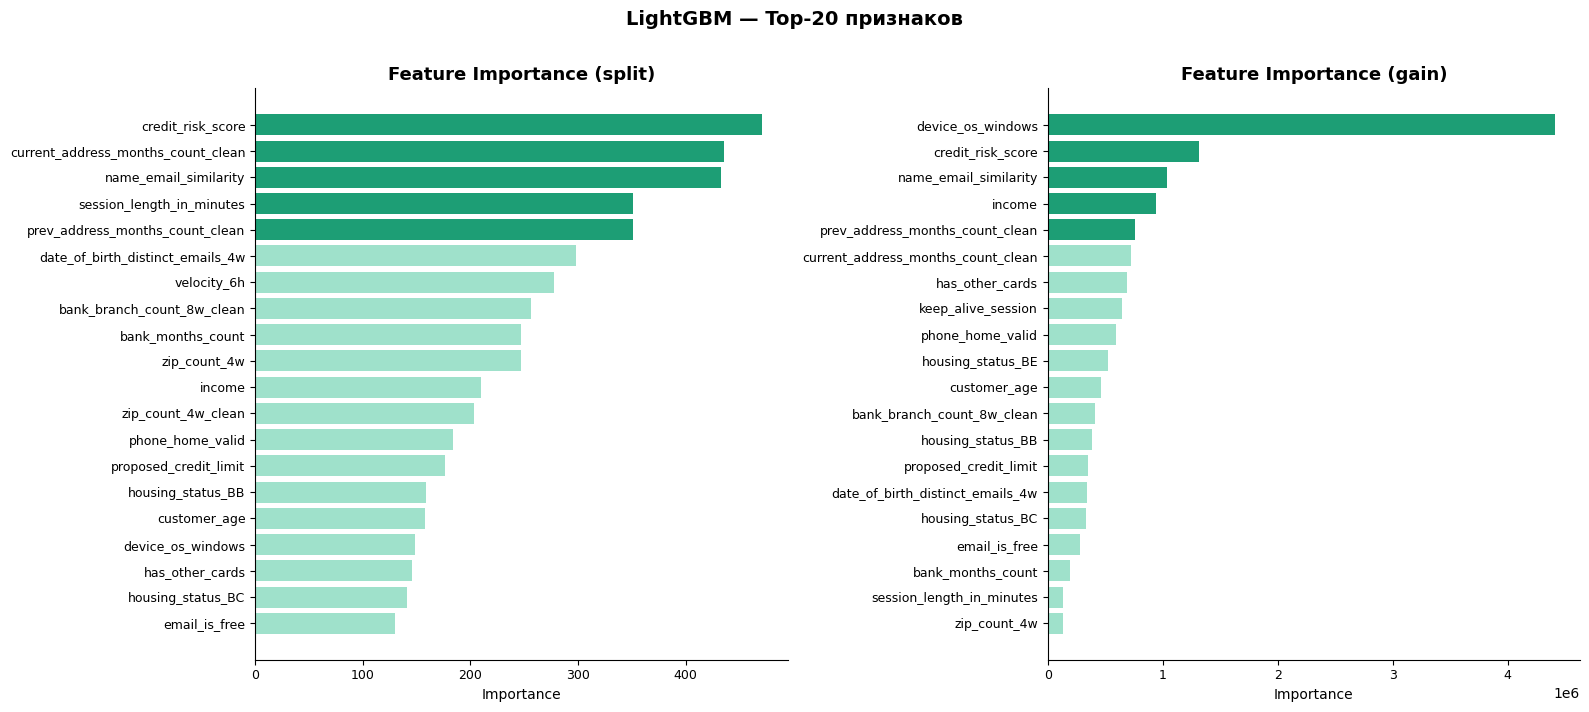

График сохранён: lgbm_feature_importance.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, imp_type in zip(axes, ['split', 'gain']):
    importances = lgbm_model.booster_.feature_importance(importance_type=imp_type)
    fi_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(20)

    colors = ['#1D9E75' if i >= len(fi_df) - 5 else '#9FE1CB'
              for i in range(len(fi_df))]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors, edgecolor='none')
    ax.set_title(f'Feature Importance ({imp_type})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=9)

plt.suptitle('LightGBM — Top-20 признаков', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: lgbm_feature_importance.png')

## SHAP-анализ
SHAP позволяет объяснить **влияние каждого признака на отдельное предсказание**

In [24]:
print('Вычисляю SHAP-значения (может занять 1–2 мин)...')

# Используем subsample для скорости — на 3000 наблюдениях
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

# Для бинарной классификации LightGBM shap_values может быть списком [neg, pos]
if isinstance(shap_values, list):
    sv = shap_values[1]   # класс 1 = фрод
else:
    sv = shap_values

print(f'SHAP-матрица: {sv.shape}')

Вычисляю SHAP-значения (может занять 1–2 мин)...
SHAP-матрица: (3000, 35)


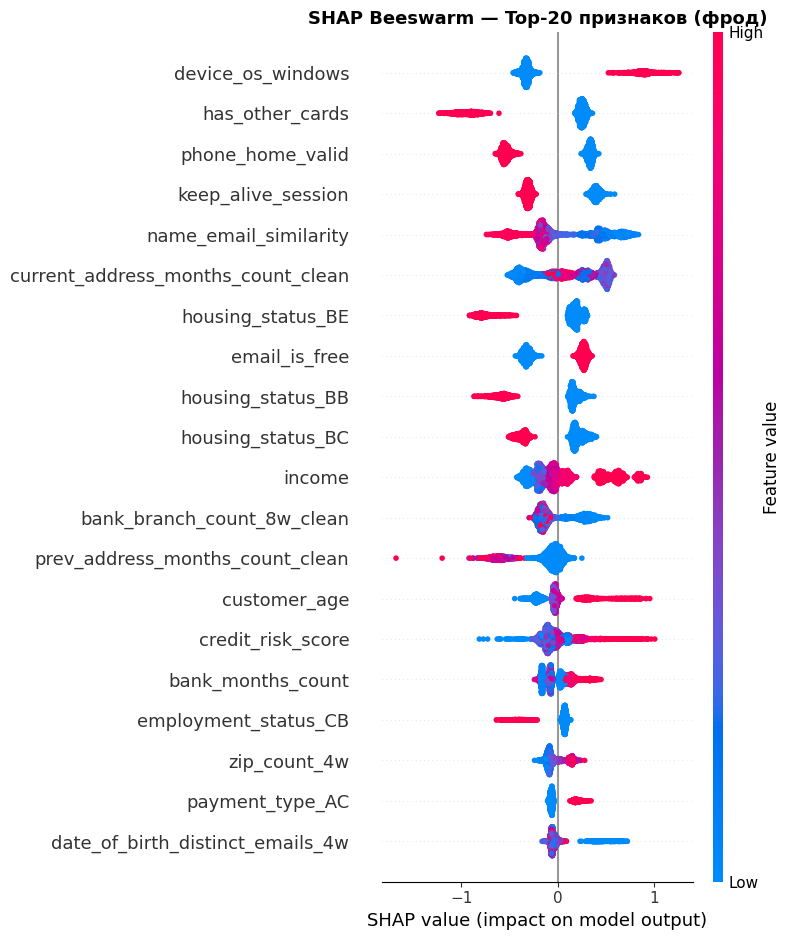

Сохранено: shap_beeswarm.png


In [25]:
#Beeswarm: глобальная важность + направление влияния
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_shap,
    feature_names=FEATURES,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Top-20 признаков (фрод)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: shap_beeswarm.png')

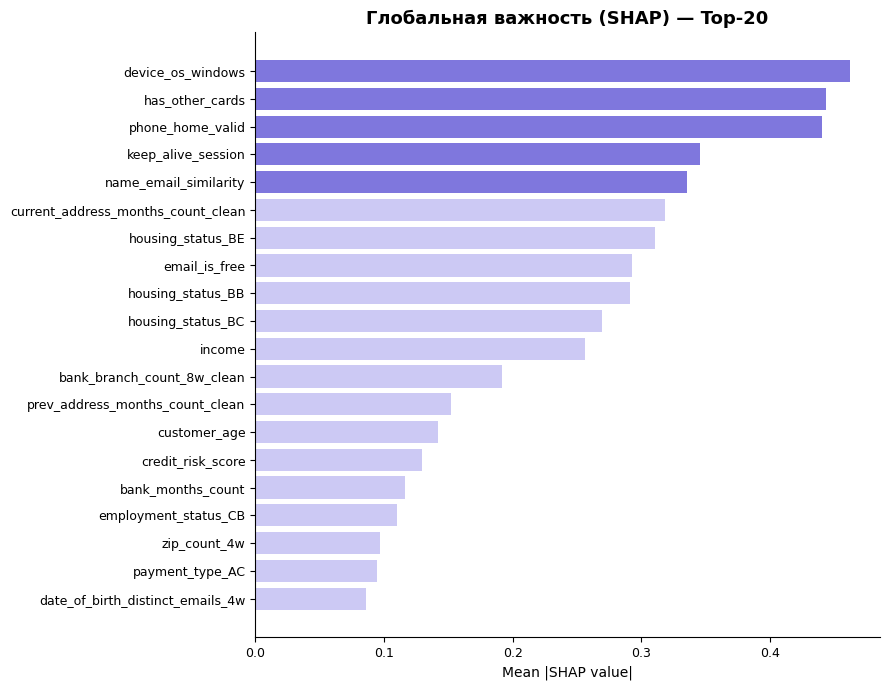

Сохранено: shap_bar.png


In [26]:
#Bar plot: средний |SHAP| по признакам
mean_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEATURES, 'mean_|shap|': mean_shap})
shap_df = shap_df.sort_values('mean_|shap|', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#7F77DD' if i >= len(shap_df) - 5 else '#CCC9F4'
          for i in range(len(shap_df))]
ax.barh(shap_df['feature'], shap_df['mean_|shap|'], color=colors, edgecolor='none')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Глобальная важность (SHAP) — Top-20', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: shap_bar.png')

Dependence plots для: ['device_os_windows', 'has_other_cards', 'phone_home_valid']


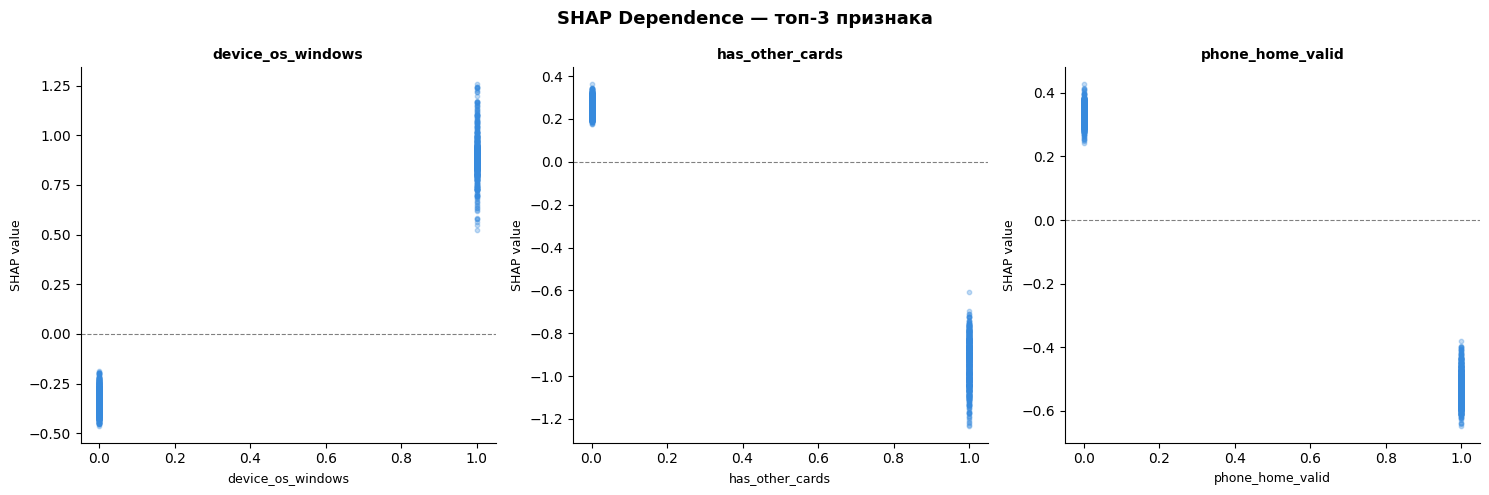

Сохранено: shap_dependence.png


In [27]:
# Dependence plot для топ-3 признаков
top3 = shap_df.tail(3)['feature'].tolist()[::-1]
print(f'Dependence plots для: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, top3):
    feat_idx = list(X_shap.columns).index(feat)
    ax.scatter(
        X_shap[feat].values,
        sv[:, feat_idx],
        alpha=0.3, s=10, color='#378ADD'
    )
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('SHAP Dependence — топ-3 признака', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: shap_dependence.png')

## Визуализация деградации на Variants
Наглядно демонстрирует мотивацию для мета-обучения.

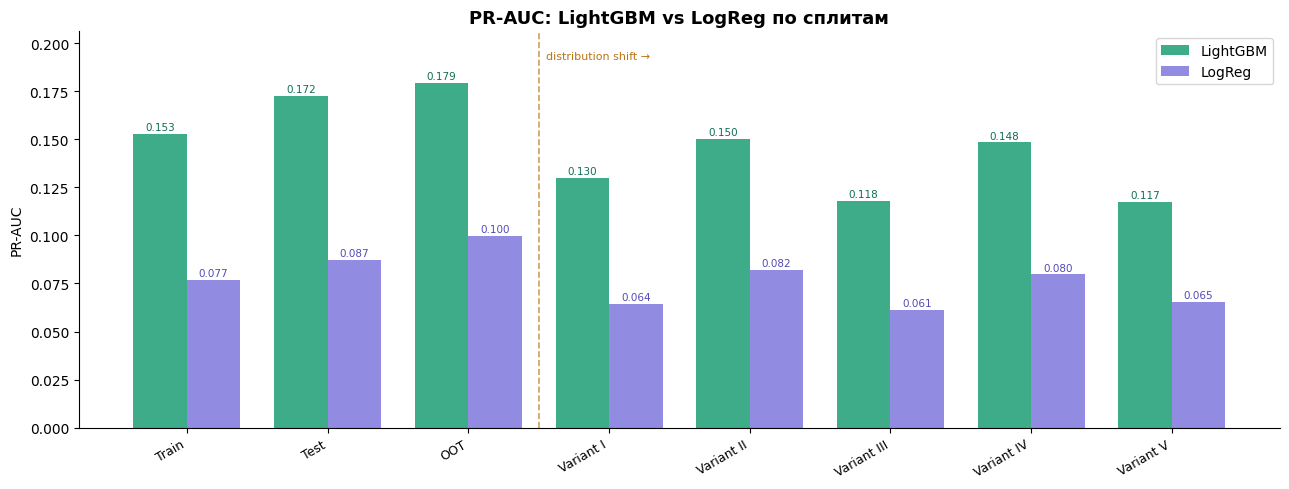

Сохранено: lgbm_vs_logreg_pr_auc.png


In [28]:
# Собираем PR-AUC по всем сплитам
labels, lgbm_pr, logreg_pr = [], [], []
for _, row in df_lgbm.iterrows():
    split = row['split']
    labels.append(split)
    lgbm_pr.append(row['PR-AUC'])
    lr_val = LOGREG_METRICS.get(split, {}).get('PR-AUC')
    logreg_pr.append(lr_val if lr_val is not None else np.nan)

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, lgbm_pr,   width, label='LightGBM', color='#1D9E75', alpha=0.85)
bars2 = ax.bar(x + width/2, logreg_pr, width, label='LogReg',   color='#7F77DD', alpha=0.85)

# Аннотации
for bar in bars1:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, color='#0F6E56')
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, color='#534AB7')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC: LightGBM vs LogReg по сплитам', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(lgbm_pr) * 1.15)

# Вертикальная линия — граница «train domain» vs Variants
oot_idx = labels.index('OOT') if 'OOT' in labels else 2
ax.axvline(x=oot_idx + 0.5, color='#BA7517', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(oot_idx + 0.55, ax.get_ylim()[1] * 0.95,
        'distribution shift →', fontsize=8, color='#BA7517', va='top')

plt.tight_layout()
plt.savefig('lgbm_vs_logreg_pr_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: lgbm_vs_logreg_pr_auc.png')

## Итог и выводы для ВКР

In [29]:
test_row = df_lgbm[df_lgbm['split'] == 'Test'].iloc[0]

print('=' * 55)
print('  LightGBM Baseline — итоговые метрики (Test)')
print('=' * 55)
print(f'  ROC-AUC : {test_row["ROC-AUC"]:.4f}')
print(f'  PR-AUC  : {test_row["PR-AUC"]:.4f}')
print(f'  F1 opt  : {test_row["F1 (opt)"]:.4f}  (порог {test_row["Threshold"]:.4f})')
print('=' * 55)
print()
print('Артефакты:')
print('  lgbm_baseline.pkl        — сохранённая модель')
print('  baseline_comparison.csv  — таблица LogReg vs LightGBM')
print('  lgbm_feature_importance.png')
print('  shap_beeswarm.png')
print('  shap_bar.png')
print('  shap_dependence.png')
print('  lgbm_vs_logreg_pr_auc.png')
print()
print('Следующий шаг (фаза 2, 8–10 апр):')
print('  → episode_sampler.py — формат эпизодов (support / query set)')

  LightGBM Baseline — итоговые метрики (Test)
  ROC-AUC : 0.8863
  PR-AUC  : 0.1723
  F1 opt  : 0.2597  (порог 0.8768)

Артефакты:
  lgbm_baseline.pkl        — сохранённая модель
  baseline_comparison.csv  — таблица LogReg vs LightGBM
  lgbm_feature_importance.png
  shap_beeswarm.png
  shap_bar.png
  shap_dependence.png
  lgbm_vs_logreg_pr_auc.png

Следующий шаг (фаза 2, 8–10 апр):
  → episode_sampler.py — формат эпизодов (support / query set)
